In [1]:
## Setup some imports and constants ##

DATA_DIRECTORY            = "./test_data"                 # The directory where data will be downloaded and extracted
HITRAN_CSIC_ZIP_FILE_NAME = "HITRAN2024_DIGITAL_CSIC.zip" # Filename of the downloaded data



### details below this line ###

from pathlib import Path

DATA_PATH = Path(DATA_DIRECTORY)
DATA_PATH.mkdir(parents=True, exist_ok=True)

HITRAN_CSIC_ZIP_PATH = DATA_PATH / HITRAN_CSIC_ZIP_FILE_NAME
HITRAN_CSIC_EXTRACT_PATH = HITRAN_CSIC_ZIP_PATH.with_suffix('')
HITRAN_CSIC_HDF5_PATH = HITRAN_CSIC_EXTRACT_PATH / 'hitran24.h5'

In [2]:
## Download HITRAN24 data from web ##

REFRESH_DATA         = False                                            # If `True` will re-download the data even if it already exists
HITRAN_CSIC_DATA_URL = "SET_THIS_TO_THE_URL_THAT_POINTS_TO_THE_DATASET" # The URL of the file to download



### details below this line ###

from pathlib import Path
from archnemesis.database.utils import fetch

if HITRAN_CSIC_DATA_URL == "SET_THIS_TO_THE_URL_THAT_POINTS_TO_THE_DATASET":
	if HITRAN_CSIC_ZIP_PATH.exists():
		print(f'`HITRAN_CSIC_DATA_URL` has not been set. However, the file has already been downloaded to {HITRAN_CSIC_ZIP_PATH!s}.')
	else:
		print(f'ERROR: `HITRAN_CSIC_DATA_URL` has not been set and the file is not already present at the expected location: {HITRAN_CSIC_ZIP_PATH!s}.')
else:
	if REFRESH_DATA or (not HITRAN_CSIC_ZIP_PATH.exists()):
		if HITRAN_CSIC_ZIP_PATH.exists():
			print(f'The file has already been downloaded, but a refresh has been requested.')
		
		print(f'Downloading data from {HITRAN_CSIC_DATA_URL}...')
		fetch.file(
			HITRAN_CSIC_DATA_URL,             # URL of the file to download
			to_fpath = HITRAN_CSIC_ZIP_PATH, # Path to download the file to
			chunk_size=10*1024*1024           # Number of bytes to download in each chunk (adjust for network efficiency)
		)
		print(f'Downloaded data saved to to {HITRAN_CSIC_ZIP_PATH!s}.')
	else:
		print(f'The file has already been downloaded to {HITRAN_CSIC_ZIP_PATH!s}.')

`HITRAN_CSIC_DATA_URL` has not been set. However, the file has already been downloaded to test_data/HITRAN2024_DIGITAL_CSIC.zip.


In [3]:
## Unzip the data ##

import zipfile

if not HITRAN_CSIC_ZIP_PATH.exists():
	print(f'ERROR: Expected zipped data file at {HITRAN_CSIC_ZIP_PATH!s}')
else:
	if REFRESH_DATA or (not HITRAN_CSIC_EXTRACT_PATH.exists()):
		if HITRAN_CSIC_EXTRACT_PATH.exists():
			print(f'Zipped data file has already been extracted, but a refresh has been requested')
		
		print(f'Extracting zipped data file at {HITRAN_CSIC_ZIP_PATH!s} ...')
		HITRAN_CSIC_EXTRACT_PATH.mkdir(parents=True, exist_ok=True)
		HITRAN_CSIC_DATA_PATHS = zipfile.ZipFile(HITRAN_CSIC_ZIP_PATH).extractall(HITRAN_CSIC_EXTRACT_PATH)
		print(f'Zipped data file has been extracted to {HITRAN_CSIC_EXTRACT_PATH!s}')
	else:
		print(f'Zipped data file has already been extracted to {HITRAN_CSIC_EXTRACT_PATH!s}')
	


Zipped data file has already been extracted to test_data/HITRAN2024_DIGITAL_CSIC


In [4]:
SHOW_DATA_TREE = False # set to `True` to print a tree representation of the data, or `False` to skip


### details below this line ###
if not HITRAN_CSIC_HDF5_PATH.exists():
	print(f'ERROR: Expected HDF5 file at {HITRAN_CSIC_HDF5_PATH!s}')

else:
	if SHOW_DATA_TREE:
		import archnemesis as ans
		import archnemesis.helpers.h5py_helper

		print(f'[FILE: {HITRAN_CSIC_HDF5_PATH!s}]\n |  ')
		ans.helpers.h5py_helper.HDF5Printer().print_file(HITRAN_CSIC_HDF5_PATH)
	else:
		print(f'Not showing tree for {HITRAN_CSIC_HDF5_PATH!s}')

Not showing tree for test_data/HITRAN2024_DIGITAL_CSIC/hitran24.h5


LineData_0::fetch_partition_fn()
Actually getting the partition function
LineData_0::fetch_partition_fn()


INFO :: create_from :: LineData_0.py-1051 :: iso_line_data._data.shape=(11, 24224)
INFO :: create_from :: LineData_0.py-1051 :: iso_line_data._data.shape=(11, 10449)


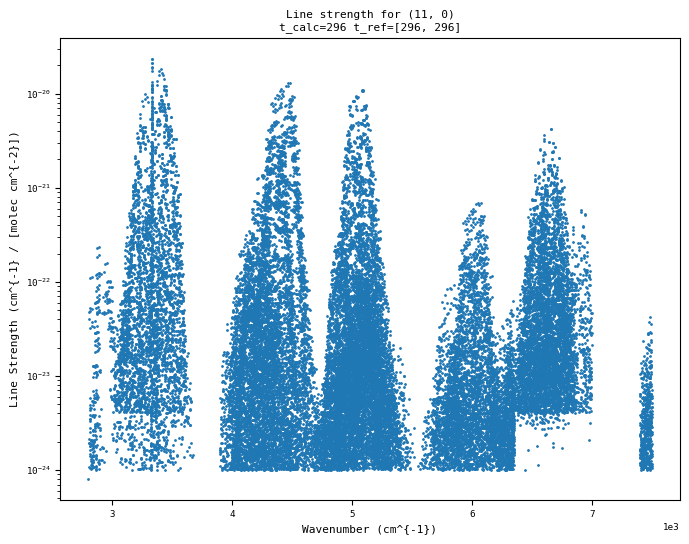

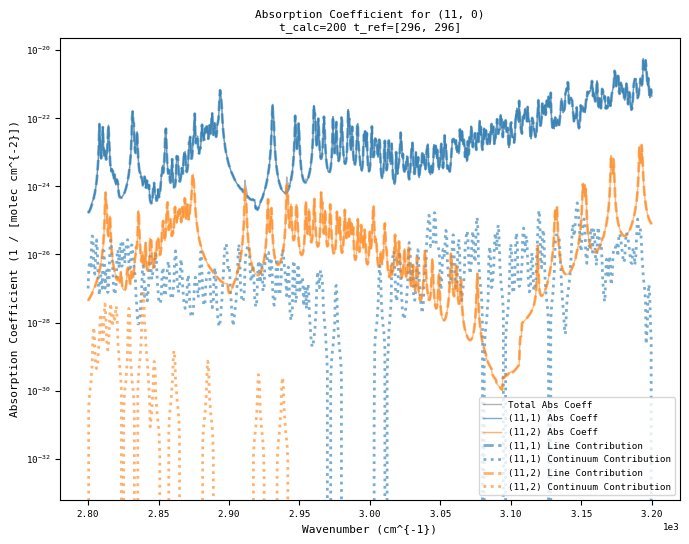

/home/dobinsonl/repos/archnemesis-dist/archnemesis/LineData_0.py:2606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


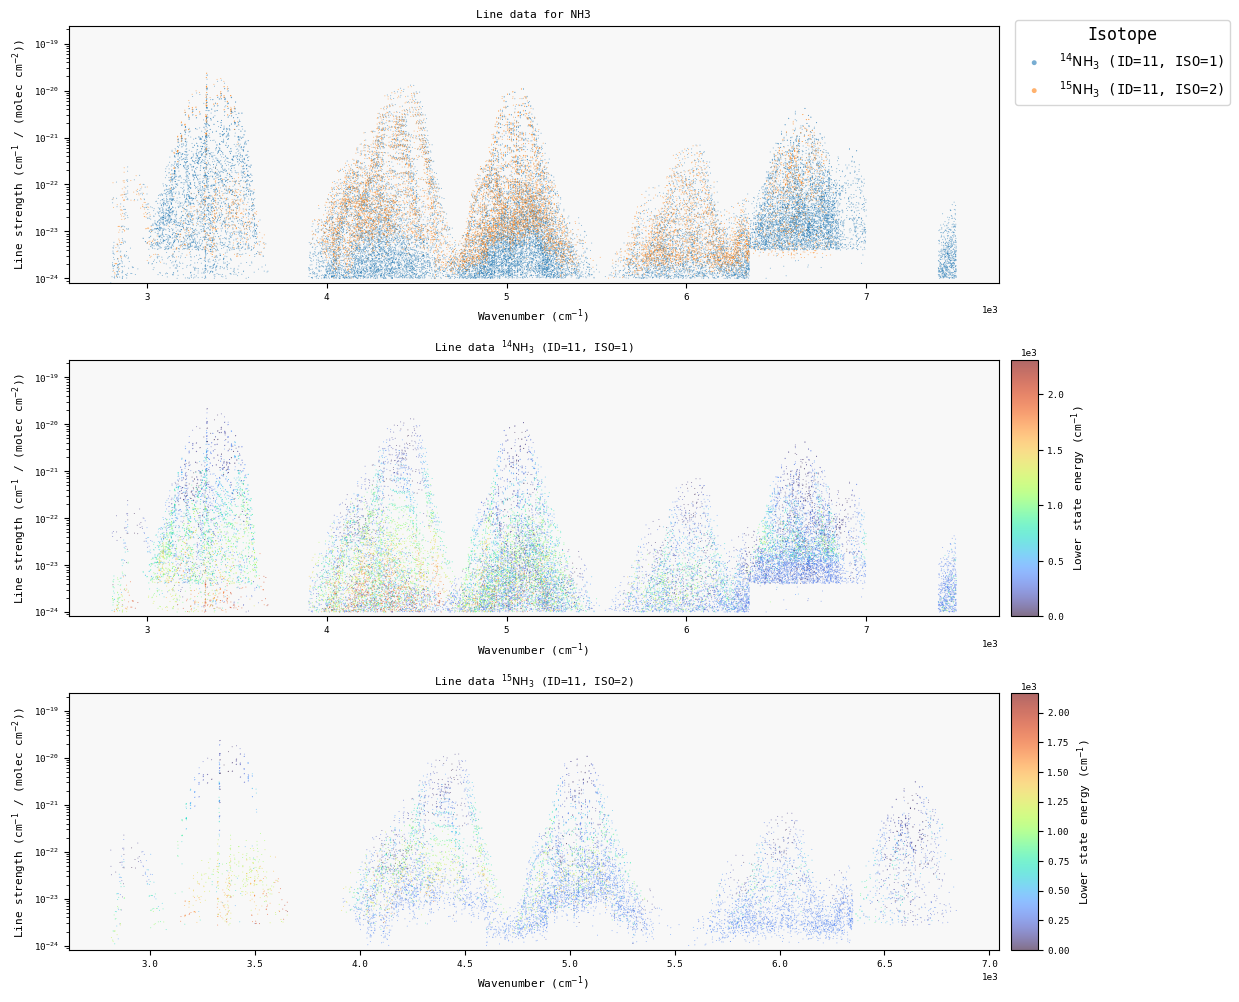

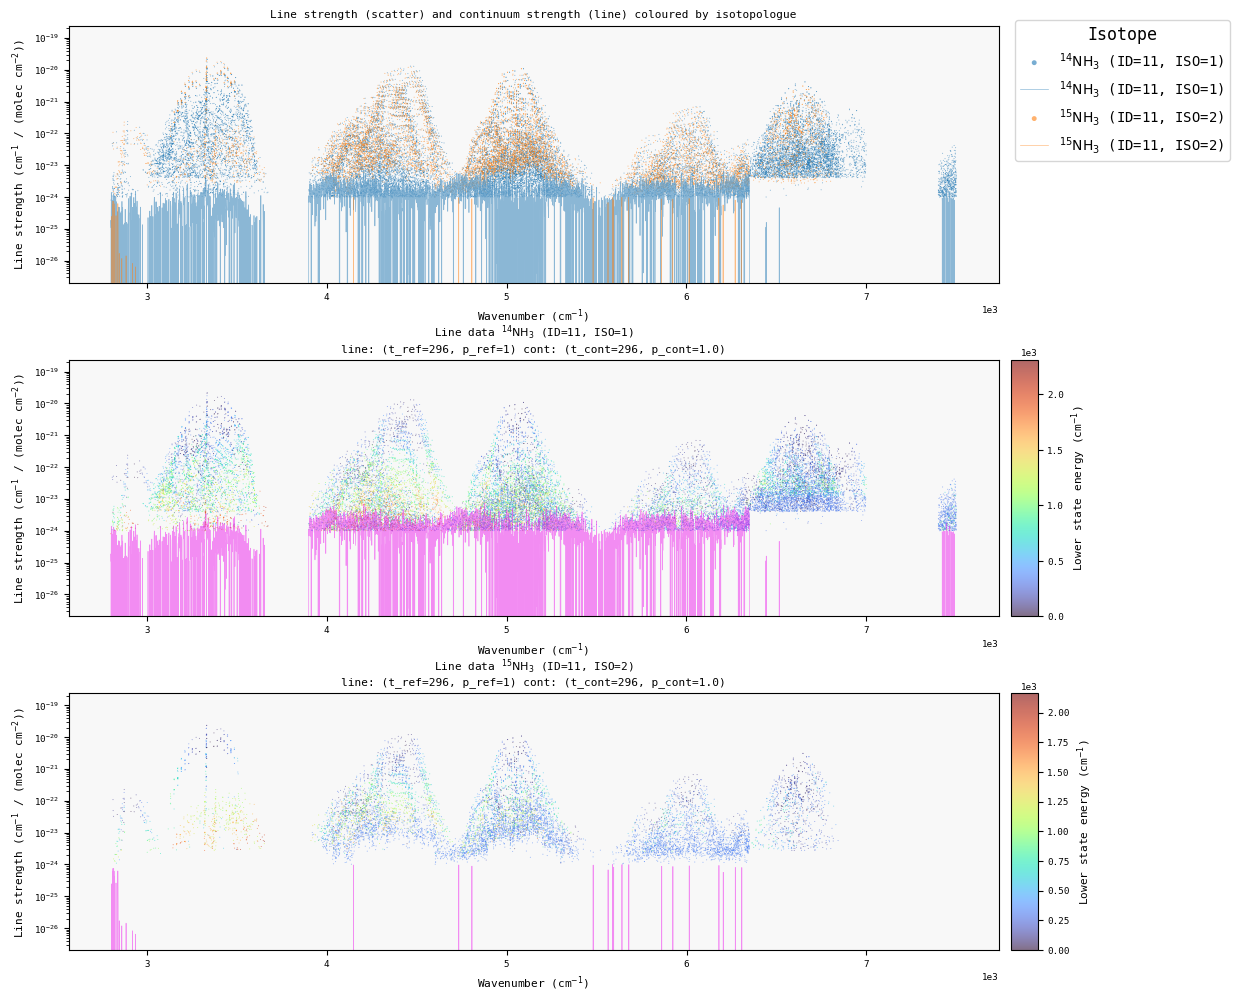

In [5]:
SHOW_EXAMPLE_PLOTS = True # set to `True` to show example plots of the data, or `False` to skip

SHOW_LINE_STRENGTH_PLOT = True
SHOW_ABSORPTION_COEFICIENT_PLOT = True
SHOW_LINE_DATA_PLOT = True
SHOW_CONTINUUM_DATA_PLOT = True

### details below this line ###

import archnemesis as ans

MOL_ID = ans.enum.GasEnum.NH3
ISO_ID = 0
AMBIENT_GASES = (ans.enum.AmbientGasEnum.AIR, )
vmin, vmax = (2800.0, 7500.0) # (cm^{-1})
S_MIN = 1E-24

PARTITION_FUNCTION_HDF5_PATH = Path(ans.Data.path_data.archnemesis_path()) / "archnemesis/Data/partition_functions/tips2025.h5"

if not SHOW_EXAMPLE_PLOTS:
	print(f'Not showing example plots for {HITRAN_CSIC_HDF5_PATH!s}')
else:
	if not HITRAN_CSIC_HDF5_PATH.exists():
		print(f'ERROR: Expected HDF5 file at {HITRAN_CSIC_HDF5_PATH!s}')
	else:
		import matplotlib.pyplot as plt
		import numpy as np
		
		gasID, isoID, ambient_gas = (
			ans.enum.GasEnum.O3, 
			0,
			ans.enum.AmbientGasEnum.AIR,
		)
		
		# Create a LineData_0 instance and load the data we need

		line_data = ans.LineData_0(
			ID = MOL_ID,
			ISO = ISO_ID,
			ambient_gasses = AMBIENT_GASES,
			LINE_DATABASE = HITRAN_CSIC_HDF5_PATH,
			PARTITION_FUNCTION_DATABASE = PARTITION_FUNCTION_HDF5_PATH,
		)

		# Set parameters for the line data we want to use
		line_data.set_params(
			vmin = vmin,
			vmax = vmax,
			s_min = S_MIN,
			#t_req = 296,
		)

		# Loading the partition function data
		line_data.fetch_partition_fn()
		
		# Loading the line data in our required spectral range.
		# NOTE: partition data is fetched as part of this function if not already fetched

		line_data.fetch_linedata()
		
		if SHOW_LINE_STRENGTH_PLOT:
			# Calculate line strengths and plot them #
			t_calc = 296 # Kelvin

			line_strengths = line_data.calculate_line_strength(t_calc=t_calc, combined_output=True)

			plt.plot(line_data.combined_line_data.NU, line_strengths, linestyle='none', marker='.', markersize=2)
			plt.title(f'Line strength for ({line_data.ID}, {line_data.ISO})\n{t_calc=} t_ref={[int(x.t_ref) for x in line_data.line_data]}')
			plt.xlabel('Wavenumber (cm^{-1})')
			plt.ylabel('Line Strength (cm^{-1} / [molec cm^{-2}])')
			plt.yscale('log')
			plt.show()
		
		if SHOW_ABSORPTION_COEFICIENT_PLOT:
			# Define a set of wavelengts to calculate absorption coefficient at and then plot them #

			t_calc = 200 # Kelvin

			waves = np.linspace(2800, 3200, 1000)
			k_abs = line_data.calculate_monochromatic_absorption(waves, t_calc=t_calc, p_calc=1, combined_output=False, each_iso_output=True, use_cache=True)
			
			
			lw_solid = 1
			lw_non_solid = 2
			colors = []
			
			plt.plot(waves, np.sum(k_abs,axis=(0,1)), color='black', alpha=0.3, marker='none', linewidth=lw_solid, linestyle='-', label='Total Abs Coeff')
			
			for j, (mol_id, iso_id) in enumerate(line_data.rt_gas_descs):
				ll = plt.plot(waves, np.sum(k_abs[:,j],axis=0), alpha=0.6, marker='none', linewidth=lw_solid, linestyle='-', label=f'({mol_id},{iso_id}) Abs Coeff')
				colors.append(ll[0].get_color())
			
			
			for j, ((mol_id, iso_id), c) in enumerate(zip(line_data.rt_gas_descs, colors)):
				
				plt.plot(waves, k_abs[0,j], alpha=0.1, color='white', marker='none', linewidth=1.2*lw_non_solid)
				plt.plot(waves, k_abs[0,j], alpha=0.6, color=c, marker='none', linewidth=lw_non_solid, linestyle='--', label=f'({mol_id},{iso_id}) Line Contribution')
				plt.plot(waves, k_abs[1,j], alpha=0.1, color='white', marker='none', linewidth=1.2*lw_non_solid)
				plt.plot(waves, k_abs[1,j], alpha=0.6, color=c, marker='none', linewidth=lw_non_solid, linestyle=':', label=f'({mol_id},{iso_id}) Continuum Contribution')
			
			plt.title(f'Absorption Coefficient for ({line_data.ID}, {line_data.ISO})\n{t_calc=} t_ref={[int(x.t_ref) for x in line_data.line_data]}')
			plt.xlabel('Wavenumber (cm^{-1})')
			plt.ylabel('Absorption Coefficient (1 / [molec cm^{-2}])')
			plt.yscale('log')
			plt.legend()
			plt.show()
		
		if SHOW_LINE_DATA_PLOT:
			line_data.plot_linedata(line_style_kw={'linewidth':0.5})
		
		if SHOW_CONTINUUM_DATA_PLOT:
			line_data.plot_continuumdata(line_style_kw={'linewidth':0.5})
